# **Meshlands - Habitability**
This notebook displays important figures allowing us to conclude about a potential habitability from our experiments.
To determine the habitability of a planet, it has been previously defined (see article) that the following conditions were realistic enough to give a general idea:
- Temperature between 273.15 K and 323.15 K,
- Precipitation above 250 mm/yr,
- More precipitation than evaporation for a given location.

Here, we first observe the continent configuration that generates the largest amount of habitable land. Then, we study the limiting condition by removing them separately.

## **Initial Set Up-related**

### Imports

In [1]:
%matplotlib inline
import sys
sys.path.append('./scripts')

########## Plotting (Matplotlib) ##########
import matplotlib.pyplot as plt

########## Python Standard Library ##########
from copy import copy
import glob

########## Dask ##########
import dask

########## NumPy ##########
import numpy as np

########## Xarray ##########
import xarray as xr

### Path Definitions

In [2]:
# Data Path
data_dir = '/scratch/st-mlague-1/mlague/data/cesm_meshland/'

### Variable Definitions

In [3]:
# Creates a list of atmospheric variables
atm_vars = ['Q','RELHUM','TMQ','LHFLX','PRECC','PRECL','T','VQ','TS']

# Creates a list of land variables
lnd_vars = ['H2OSOI']

### Dictionary Definitions

In [4]:
# Creates a new case list
case_list = ['cesm_f09_mesh4_avgemiss_450ppm_thermice2',
             'cesm_f09_mesh8_avgemiss_450ppm_thermice2',
             'cesm_f09_mesh16_avgemiss_450ppm_thermice2']

# Creates a dictionary of the short names for each case in case_list
short_names = {}
short_names['cesm_f09_mesh4_avgemiss_450ppm_thermice2'] = 'mesh4'
short_names['cesm_f09_mesh8_avgemiss_450ppm_thermice2'] = 'mesh8'
short_names['cesm_f09_mesh16_avgemiss_450ppm_thermice2'] = 'mesh16'

# create a list of cases
config = list(short_names.values())

In [5]:
# Creates an empty data set dictionary
ds_dict = {}

# Creates an empty time series dictionary for the atmospheric and the land variables
ts_dict_atm = {}
ts_dict_lnd = {}

# Creates an empty dictionary for the meshlands geographical configuration
mesh_dict = {}
mesh4_dict = xr.open_dataset("/scratch/st-mlague-1/mlague/data/cesm_meshland/inputs/fracdata_0.9x1.25_meshland4.nc")
mesh8_dict = xr.open_dataset("/scratch/st-mlague-1/mlague/data/cesm_meshland/inputs/fracdata_0.9x1.25_meshland8.nc")
mesh16_dict = xr.open_dataset("/scratch/st-mlague-1/mlague/data/cesm_meshland/inputs/fracdata_0.9x1.25_meshland16.nc")
mesh_dict['mesh4'] = mesh4_dict
mesh_dict['mesh8'] = mesh8_dict
mesh_dict['mesh16'] = mesh16_dict

# Overall: using dask to split large chunks of the array to avoid a surcharge
with dask.config.set(**{'array.slicing.split_large_chunks': True}):

    # For each case in the case list,
    # prints the name of the case
    for case in case_list:
        print(case)

        # Defines the time series directory name for the case
        ts_dir = data_dir + '/' + case + '/TimeSeries/'

        # Creates an empty file list for the atmospheric variables
        file_list_atm = []
        file_list_lnd = [] 

        # For each variable in the set of atmospheric variables
        for var in atm_vars:

            # Finds the variable's file for that case
            files = glob.glob(ts_dir+'/'+case+'.cam.h0.ts.0-end.'+var+'.nc')

            # If the file does not exist, print a message
            # Else, append the files to the atmospheric file list
            if len(files)<1:
                print('oh no, no variables for %s'%var)
            else:
                for file in files:
                    file_list_atm.append(file)

        # For each variables in the set of land variables
        for var in lnd_vars:

            # Finds the variable's file for that case
            files = glob.glob(ts_dir+'/'+case+'.clm2.h0.ts.0-end.'+var+'.nc')

            # If the file does not exist, print a message
            # Else, append the files to the land file list
            if len(files)<1:
                print('oh no, no variables for %s'%var)
            else:
                for file in files:
                    file_list_lnd.append(file)

        # Creates temporary atmospheric and land data sets
        ds_temp_atm = xr.open_mfdataset(file_list_atm,engine='netcdf4',compat='override')
        ds_temp_lnd = xr.open_mfdataset(file_list_lnd,engine='netcdf4',compat='override')

        # Drops the first 30 years, and keeps data up to year 60
        if case == 'cesm_f09_mesh16_avgemiss_450ppm_thermice2':
            ds_temp_atm_short = ds_temp_atm.isel(time=slice((27-1)*12-1,56*12-1))
            ds_temp_lnd_short = ds_temp_lnd.isel(time=slice((27-1)*12-1,56*12-1))
        else:
            ds_temp_atm_short = ds_temp_atm.isel(time=slice((30-1)*12-1,60*12-1))
            ds_temp_lnd_short = ds_temp_lnd.isel(time=slice((30-1)*12-1,60*12-1))

        # Assigns the case's short name to short
        short = short_names[case]

        # Creates a copy of the temporary atmospheric and land data sets,
        # then assigns them to an entry in their respective dictionaries
        ts_dict_atm[short] = copy(ds_temp_atm_short)
        ts_dict_lnd[short] = copy(ds_temp_lnd_short)

        # Deletes the temporary data sets
        del ds_temp_atm, ds_temp_atm_short, ds_temp_lnd, ds_temp_lnd_short

cesm_f09_mesh4_avgemiss_450ppm_thermice2
cesm_f09_mesh8_avgemiss_450ppm_thermice2
cesm_f09_mesh16_avgemiss_450ppm_thermice2


# **Habitability**

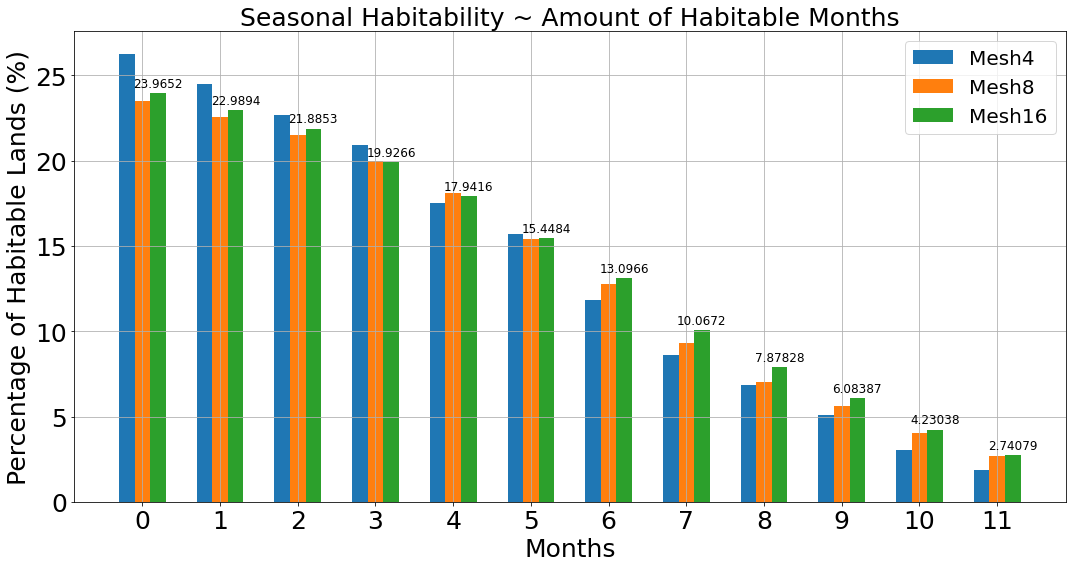

In [6]:
# Overall: plots a bar chart showing the amount of habitable land for a certain duration for all meshes

# Creates an empty dictionary to store the data
per_habitable = {}

for case in config:
    
    # Groups the case's atmospheric time series dictionary by year, calculates the mean
    ds_case = ts_dict_atm[case].groupby('time.month').mean('time')

    # Collects the mesh datas to select ocean/land values
    mask = mesh_dict[case]['mask'].values.copy()

    # Creates an array to store the amount of habitable land for each case
    compteur = np.zeros_like(mask, dtype=float)
    
    for i,month in enumerate(ds_case.month):
    
        # Collects and adapts the needed variables to evaluate the habitability
        Delta_P = 3600 * 1000 * 24 * 365 * (ds_case['PRECL'].isel(month=i) + ds_case['PRECC'].isel(month=i)) - (ds_case['LHFLX'].isel(month=i)) / 2.501e6 * 3600 * 24 * 365
        Temp = ds_case['TS'].isel(month=i)
        P = 3600 * 1000 * 24 * (ds_case['PRECL'].isel(month=i) + ds_case['PRECC'].isel(month=i)) * 365

        # Calculates the habitability condition for all the map
        is_land = (mask == 1)
        is_habitable = ((Temp.values >= 273.15) & (Temp.values <= 323.15) & (Delta_P.values >= 0) & (P.values >= 250))

        # Updates the compteur if habitability conditions are reached
        compteur[is_land & is_habitable] += 1

    # Converts Numpy array into an Xarray to conserve lat and lon dimensions
    compteur_da = xr.DataArray(compteur,dims=ds_case['TS'].isel(month=0).dims,coords=ds_case['TS'].isel(month=0).coords)

    # Converts the mask and weight arrays into DataArray to ease vector computation
    yc = mesh_dict[case]["yc"].values
    weights_da = xr.DataArray(np.clip(np.cos(np.deg2rad(yc)), 0, None), dims=('lat', 'lon'))
    mask_da = xr.DataArray(mask, dims=('lat', 'lon'))

    # Calculates the weighted amount of land grid cells of the simulation
    is_land_da = (mask_da == 1) | (mask_da == 2)
    weighted_land = is_land_da.weighted(weights_da).sum()

    # Calculates the percentage of habitable land for each time period
    per_habitable[case] = []
    for i in range(1,13):
        is_habitable_da = (compteur_da >= i)
        weighted_habitable = is_habitable_da.weighted(weights_da).sum()
        percentage_habitable = 100 * float(weighted_habitable) / float(weighted_land)
        per_habitable[case].append(percentage_habitable)

# Prepares the plot
months = [str(i) for i in range(1, 13)]
mesh4 = per_habitable['mesh4']
mesh8 = per_habitable['mesh8']
mesh16 = per_habitable['mesh16']

x = np.arange(len(months))  # the label locations
width = 0.2  # the width of the bars

fig, ax = plt.subplots(figsize=(15,8))
rects1 = ax.bar(x - width, mesh4, width, label='Mesh4')
rects2 = ax.bar(x, mesh8, width, label='Mesh8')
rects3 = ax.bar(x + width, mesh16, width, label='Mesh16')

# Adds some text for labels, title and custom x-axis tick labels, etc.
ax.set_ylabel('Percentage of Habitable Lands (%)',fontsize=25)
ax.set_title('Seasonal Habitability ~ Amount of Habitable Months',fontsize=25)
ax.set_xticks(x)
ax.set_xlabel('Months', fontsize=25)

ax.tick_params(labelsize=25)
ax.legend(fontsize=20)

ax.bar_label(rects3, padding=3, fontsize=12)

fig.tight_layout()

plt.grid()
plt.show()
plt.close()

## **Limitant condition**

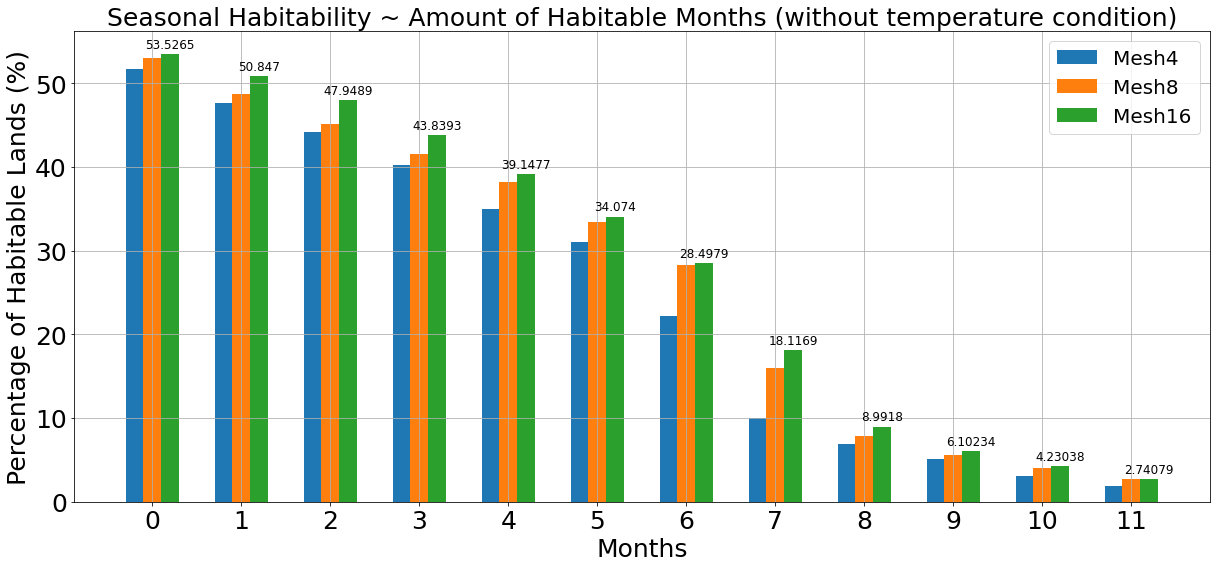

In [7]:
# Overall: plots a bar chart showing the amount of habitable land for a certain duration for all meshes (without the temperature condition)

# Creates an empty dictionary to store the data
per_habitable = {}

for case in config:

    # Groups the case's atmospheric time series dictionary by year, calculates the mean
    ds_case = ts_dict_atm[case].groupby('time.month').mean('time')

    # Collects the mesh datas to select ocean/land values
    mask = mesh_dict[case]['mask'].values.copy()
    
    # Creates an array to store the amount of habitable land for each case
    compteur = np.zeros_like(mask, dtype=float)

    for i,month in enumerate(ds_case.month):
    
        # Collects and adapts the needed variables to evaluate the habitability
        Delta_P = 3600 * 1000 * 24 * 365 * (ds_case['PRECL'].isel(month=i) + ds_case['PRECC'].isel(month=i)) - (ds_case['LHFLX'].isel(month=i)) / 2.501e6 * 3600 * 24 * 365
        Temp = ds_case['TS'].isel(month=i)
        P = 3600 * 1000 * 24 * (ds_case['PRECL'].isel(month=i) + ds_case['PRECC'].isel(month=i)) * 365

        # Calculates the habitability condition for all the map
        is_land = (mask == 1)
        is_habitable = ((Delta_P.values >= 0) & (P.values >= 250))
        
        # Updates the compteur if habitability conditions are reached
        compteur[is_land & is_habitable] += 1

    # Converts Numpy array into an Xarray to conserve lat and lon dimensions
    compteur_da = xr.DataArray(compteur,dims=ds_case['TS'].isel(month=0).dims,coords=ds_case['TS'].isel(month=0).coords)

    # Converts the mask and weight arrays into DataArray to ease vector computation
    yc = mesh_dict[case]["yc"].values
    weights_da = xr.DataArray(np.clip(np.cos(np.deg2rad(yc)), 0, None), dims=('lat', 'lon'))  # adaptez les noms de dims à votre grille
    mask_da = xr.DataArray(mask, dims=('lat', 'lon'))
    
    # Calculates the weighted amount of land grid cells of the simulation
    is_land_da = (mask_da == 1) | (mask_da == 2)
    weighted_land = is_land_da.weighted(weights_da).sum()

    # Calculates the percentage of habitable land for each time period
    per_habitable[case] = []
    for i in range(1,13):
        is_habitable_da = (compteur_da >= i)
        weighted_habitable = is_habitable_da.weighted(weights_da).sum()
        percentage_habitable = 100 * float(weighted_habitable) / float(weighted_land)

        per_habitable[case].append(percentage_habitable)

# Prepares the plot
months = [str(i) for i in range(1, 13)]
mesh4 = per_habitable['mesh4']
mesh8 = per_habitable['mesh8']
mesh16 = per_habitable['mesh16']

x = np.arange(len(months))  # the label locations
width = 0.2  # the width of the bars

fig, ax = plt.subplots(figsize=(17,8))
rects1 = ax.bar(x - width, mesh4, width, label='Mesh4')
rects2 = ax.bar(x, mesh8, width, label='Mesh8')
rects3 = ax.bar(x + width, mesh16, width, label='Mesh16')

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_ylabel('Percentage of Habitable Lands (%)',fontsize=25)
ax.set_title('Seasonal Habitability ~ Amount of Habitable Months (without temperature condition)',fontsize=25)
ax.set_xticks(x)
ax.set_xlabel('Months', fontsize=25)

ax.tick_params(labelsize=25)
ax.legend(fontsize=20)

ax.bar_label(rects3, padding=3, fontsize=12)

fig.tight_layout()

plt.grid()
plt.show()
plt.close()

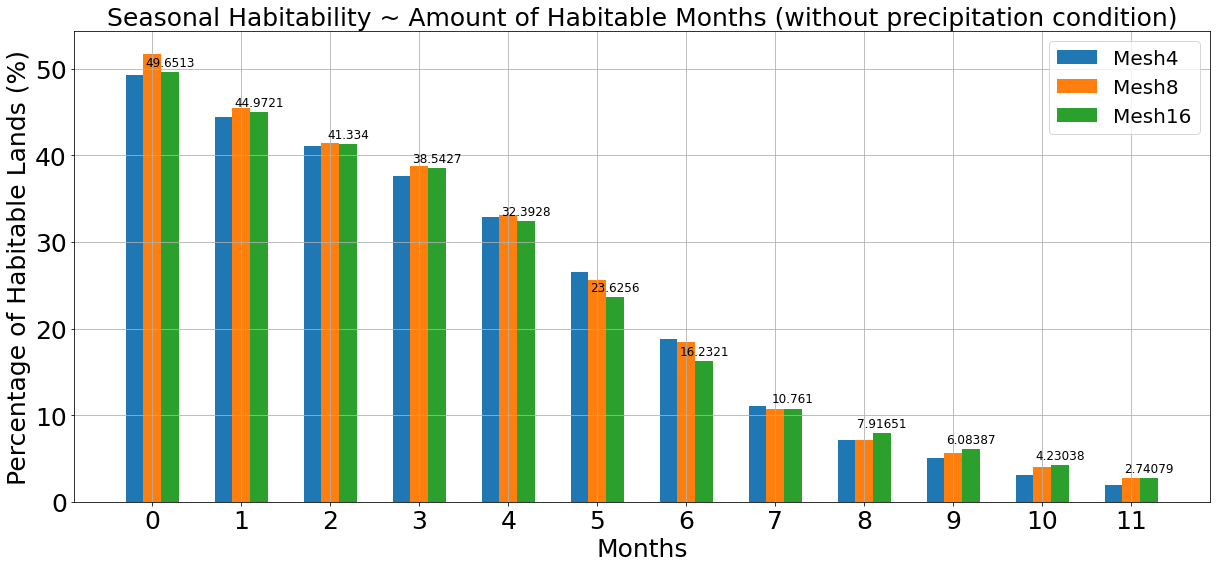

In [8]:
# Overall: plots a bar chart showing the amount of habitable land for a certain duration for all meshes (without the Precipitation condition)

# Creates an empty dictionary to store the data
per_habitable = {}

for case in config:

    # Groups the case's atmospheric time series dictionary by year, calculates the mean
    ds_case = ts_dict_atm[case].groupby('time.month').mean('time')

    # Collects the mesh datas to select ocean/land values
    mask = mesh_dict[case]['mask'].values.copy()
    
    # Creates an array to store the amount of habitable land for each case
    compteur = np.zeros_like(mask, dtype=float)
    
    for i,month in enumerate(ds_case.month):
    
        # Collects and adapts the needed variables to evaluate the habitability
        Delta_P = 3600 * 1000 * 24 * 365 * (ds_case['PRECL'].isel(month=i) + ds_case['PRECC'].isel(month=i)) - (ds_case['LHFLX'].isel(month=i)) / 2.501e6 * 3600 * 24 * 365
        Temp = ds_case['TS'].isel(month=i)
        P = 3600 * 1000 * 24 * (ds_case['PRECL'].isel(month=i) + ds_case['PRECC'].isel(month=i)) * 365

        # Calculates the habitability condition for all the map
        is_land = (mask == 1)
        is_habitable = ((Temp.values >= 273.15) & (Temp.values <= 323.15) & (Delta_P.values >= 0))
        
        # Updates the compteur if habitability conditions are reached
        compteur[is_land & is_habitable] += 1

    # Converts of Numpy array into an Xarray to conserve lat and lon dimensions
    compteur_da = xr.DataArray(compteur,dims=ds_case['TS'].isel(month=0).dims,coords=ds_case['TS'].isel(month=0).coords)

    # Converts the mask and weight arrays into DataArray to ease vector computation
    yc = mesh_dict[case]["yc"].values
    weights_da = xr.DataArray(np.clip(np.cos(np.deg2rad(yc)), 0, None), dims=('lat', 'lon'))  # adaptez les noms de dims à votre grille
    mask_da = xr.DataArray(mask, dims=('lat', 'lon'))
    
    # Calculates the weighted amount of land grid cells of the simulation
    is_land_da = (mask_da == 1) | (mask_da == 2)
    weighted_land = is_land_da.weighted(weights_da).sum()

    # Calculates the percentage of habitable land for each time period
    per_habitable[case] = []
    for i in range(1,13):
        is_habitable_da = (compteur_da >= i)
        weighted_habitable = is_habitable_da.weighted(weights_da).sum()
        percentage_habitable = 100 * float(weighted_habitable) / float(weighted_land)

        per_habitable[case].append(percentage_habitable)

# Prepares the plot
months = [str(i) for i in range(1, 13)]
mesh4 = per_habitable['mesh4']
mesh8 = per_habitable['mesh8']
mesh16 = per_habitable['mesh16']

x = np.arange(len(months))  # the label locations
width = 0.2  # the width of the bars

fig, ax = plt.subplots(figsize=(17,8))
rects1 = ax.bar(x - width, mesh4, width, label='Mesh4')
rects2 = ax.bar(x, mesh8, width, label='Mesh8')
rects3 = ax.bar(x + width, mesh16, width, label='Mesh16')

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_ylabel('Percentage of Habitable Lands (%)',fontsize=25)
ax.set_title('Seasonal Habitability ~ Amount of Habitable Months (without precipitation condition)',fontsize=25)
ax.set_xticks(x)
ax.set_xlabel('Months', fontsize=25)

ax.tick_params(labelsize=25)
ax.legend(fontsize=20)

ax.bar_label(rects3, padding=3, fontsize=12)

fig.tight_layout()

plt.grid()
plt.show()
plt.close()

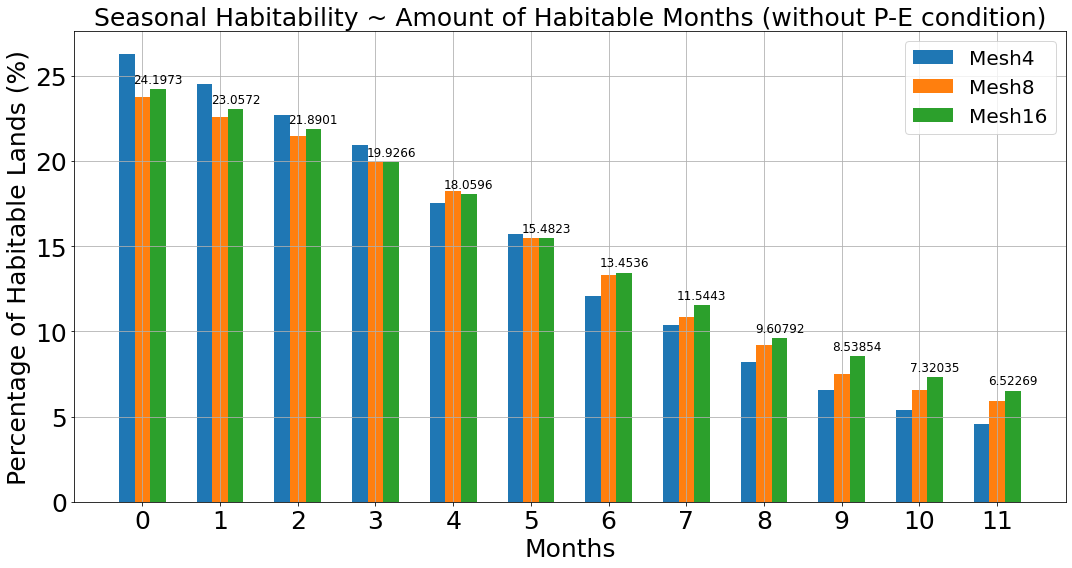

In [9]:
# Overall: plots a bar chart showing the amount of habitable land for a certain duration for all meshes (without the delta P-E condition)

# Creates an empty dictionary to store the data
per_habitable = {}

for case in config:

    # Groups the case's atmospheric time series dictionary by year, calculates the mean
    ds_case = ts_dict_atm[case].groupby('time.month').mean('time')

    # Collects the mesh datas to select ocean/land values
    mask = mesh_dict[case]['mask'].values.copy()
    
    # Creates an array to store the amount of habitable land for each case
    compteur = np.zeros_like(mask, dtype=float)
    
    for i,month in enumerate(ds_case.month):
    
        # Collects and adapts the needed variables to evaluate the habitability
        Delta_P = 3600 * 1000 * 24 * 365 * (ds_case['PRECL'].isel(month=i) + ds_case['PRECC'].isel(month=i)) - (ds_case['LHFLX'].isel(month=i)) / 2.501e6 * 3600 * 24 * 365
        Temp = ds_case['TS'].isel(month=i)
        P = 3600 * 1000 * 24 * (ds_case['PRECL'].isel(month=i) + ds_case['PRECC'].isel(month=i)) * 365

        # Calculates the habitability condition for all the map
        is_land = (mask == 1)
        is_habitable = ((Temp.values >= 273.15) & (Temp.values <= 323.15) & (P.values >= 250))
        
        # Updates the compteur if habitability conditions are reached
        compteur[is_land & is_habitable] += 1

    # Converts Numpy array into an Xarray to conserve lat and lon dimensions
    compteur_da = xr.DataArray(compteur,dims=ds_case['TS'].isel(month=0).dims,coords=ds_case['TS'].isel(month=0).coords)

    # Converts the mask and weight arrays into DataArray to ease vector computation
    yc = mesh_dict[case]["yc"].values
    weights_da = xr.DataArray(np.clip(np.cos(np.deg2rad(yc)), 0, None), dims=('lat', 'lon'))  # adaptez les noms de dims à votre grille
    mask_da = xr.DataArray(mask, dims=('lat', 'lon'))
    
    # Calculates the weighted amount of land grid cells of the simulation
    is_land_da = (mask_da == 1) | (mask_da == 2)
    weighted_land = is_land_da.weighted(weights_da).sum()

    # Calculates the percentage of habitable land for each time period
    per_habitable[case] = []
    for i in range(1,13):
        is_habitable_da = (compteur_da >= i)
        weighted_habitable = is_habitable_da.weighted(weights_da).sum()
        percentage_habitable = 100 * float(weighted_habitable) / float(weighted_land)

        per_habitable[case].append(percentage_habitable)

# Prepares the plot
months = [str(i) for i in range(1, 13)]
mesh4 = per_habitable['mesh4']
mesh8 = per_habitable['mesh8']
mesh16 = per_habitable['mesh16']

x = np.arange(len(months))  # the label locations
width = 0.2  # the width of the bars

fig, ax = plt.subplots(figsize=(15,8))
rects1 = ax.bar(x - width, mesh4, width, label='Mesh4')
rects2 = ax.bar(x, mesh8, width, label='Mesh8')
rects3 = ax.bar(x + width, mesh16, width, label='Mesh16')

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_ylabel('Percentage of Habitable Lands (%)',fontsize=25)
ax.set_title('Seasonal Habitability ~ Amount of Habitable Months (without P-E condition)',fontsize=25)
ax.set_xticks(x)
ax.set_xlabel('Months', fontsize=25)

ax.tick_params(labelsize=25)
ax.legend(fontsize=20)

ax.bar_label(rects3, padding=3, fontsize=12)

fig.tight_layout()

plt.grid()
plt.show()
plt.close()